## Importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Ler as bases de dados

In [6]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocations = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

## Verifica se os datasets foram criados   

In [5]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)


## Pergunta Norteadora
#### “Quais fatores mais influenciam a satisfação do cliente no e-commerce e como a empresa pode atuar sobre eles para melhorar a experiência e aumentar a fidelização?”

### Hipótese 1: A categoria influencia na satisfação?

### Preparação dos dados

In [48]:
## Juntar itens com produtos (para pegar categoria)

items_with_products = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

## Juntar itens com produtos (para pegar categoria)

items_full = items_with_products.merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

## Agregar para ter uma linha por pedido

##order_summary = (
##    items_full
##   .groupby("order_id")
##   .agg({
##       "product_id": list,
##        "product_category_name": lambda x: list(set(x)),
##        "review_score": "first"
##    })
##    .reset_index()
##)

## Visualizar tabela final

items_full.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,5.0


In [49]:
category_summary = (
    items_full
    .groupby("product_category_name")
    .agg(
        avg_review=("review_score", "mean"),
        num_reviews=("review_score", "count")
    )
    .reset_index()
)

<Axes: title={'center': 'Avaliação média por categoria'}, ylabel='product_category_name'>

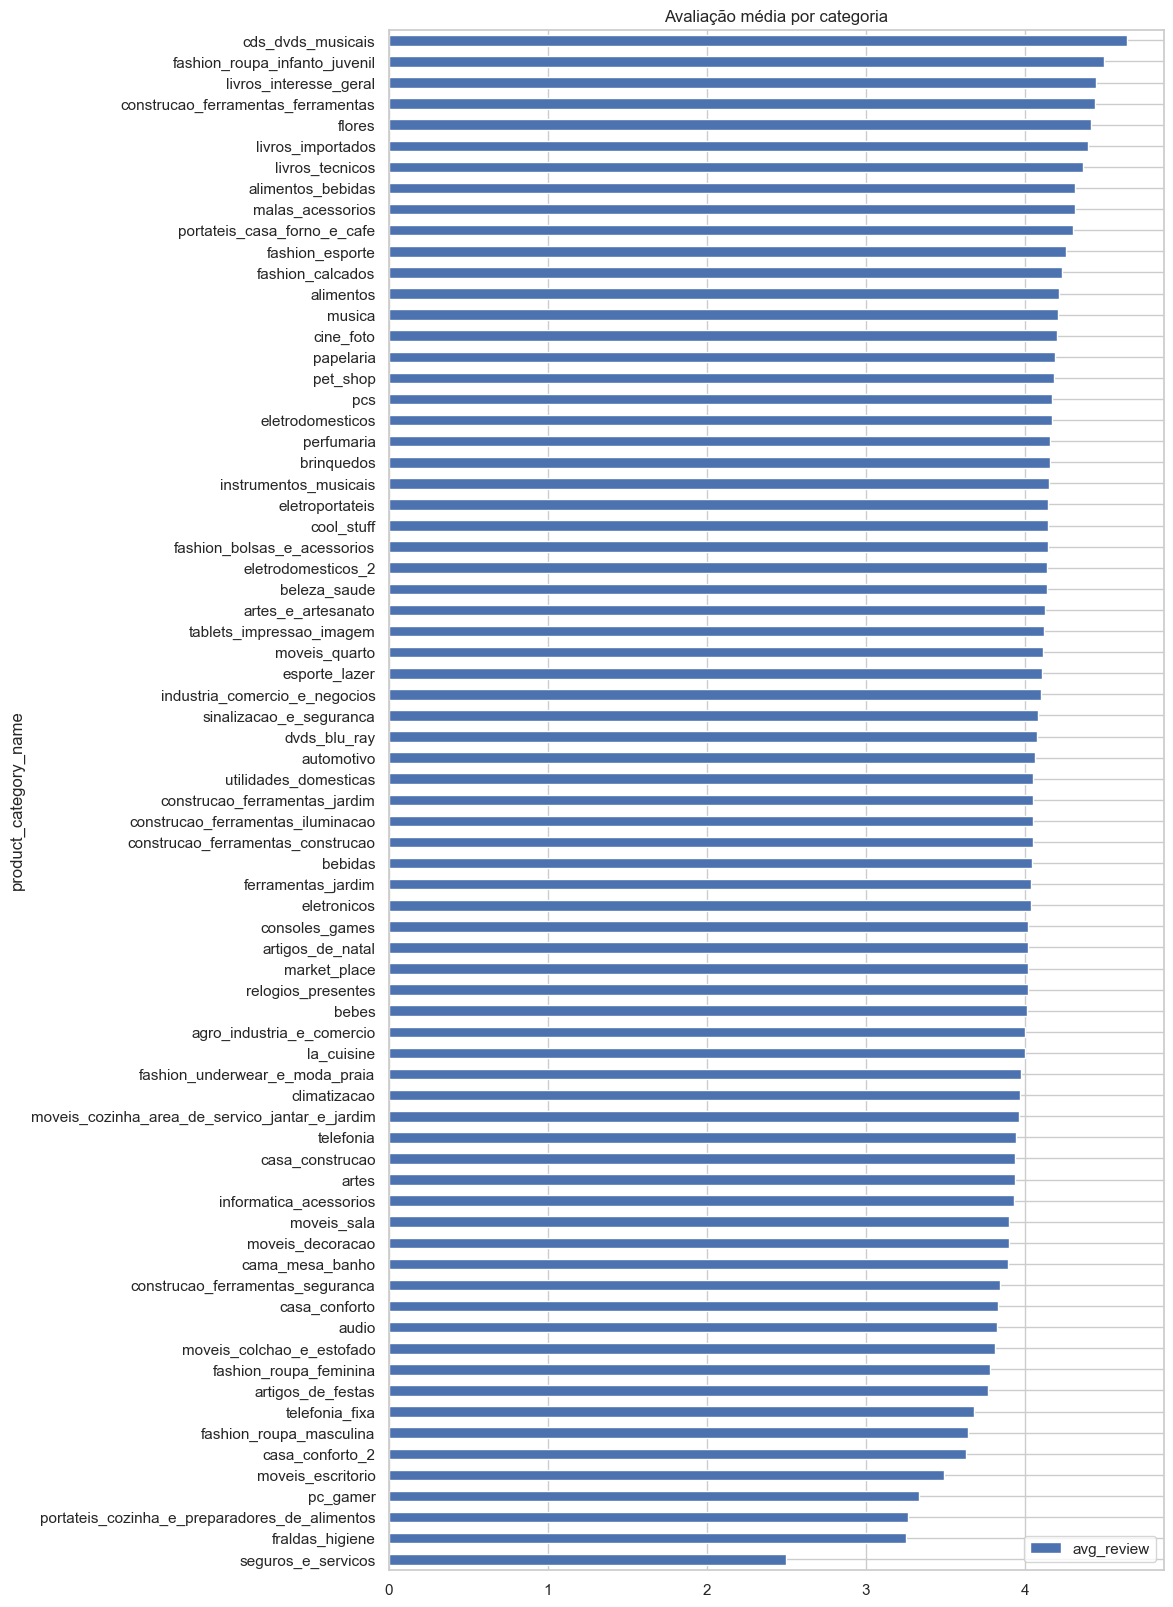

In [59]:


category_summary.sort_values(
    by="avg_review"
).plot(
    y="avg_review",
    x="product_category_name",
    kind="barh",
    figsize=(10, 20),
    title="Avaliação média por categoria"
)


### Distribuição da avaliações

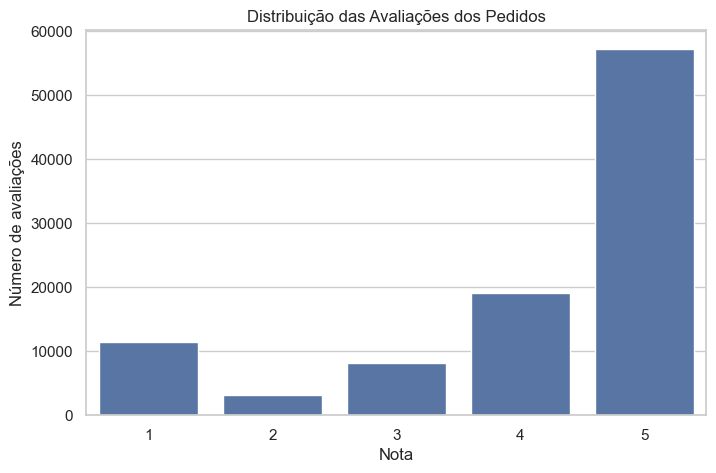

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=order_reviews,
    x="review_score",
    order=sorted(order_reviews["review_score"].unique())
)

plt.title("Distribuição das Avaliações dos Pedidos")
plt.xlabel("Nota")
plt.ylabel("Número de avaliações")

plt.show()

In [8]:
import duckdb

query = """
SELECT
    oi.seller_id,
    COUNT(DISTINCT oi.order_id) AS num_pedidos,
    AVG(orv.review_score) AS avg_review
FROM order_reviews orv
JOIN order_items oi
ON orv.order_id = oi.order_id
GROUP BY oi.seller_id
ORDER BY avg_review DESC

"""

resultado = duckdb.query(query).to_df()

resultado

,seller_id,num_pedidos,avg_review
0,9140ef75cc8211c4035935e80e567204,1,5.0
1,e82de6494d91d3c4c54450f59b227a94,2,5.0
2,6c17baf138731a4aaacc3210adf2037b,4,5.0
3,53b0300ca793f9834cd69c0678d35ee8,5,5.0
4,6a3139c7bf09ece22a4713d956acbe5e,1,5.0
...,...,...,...
3085,c004e5ea15737026cecaee0447e00b75,2,1.0
3086,f3055483058c84d75ca2a3314fb4deef,1,1.0
3087,ad8ada0ffa993cb1197d102d9ab21a3e,1,1.0
3088,9c3a1c416c765687bc79a04113269929,1,1.0


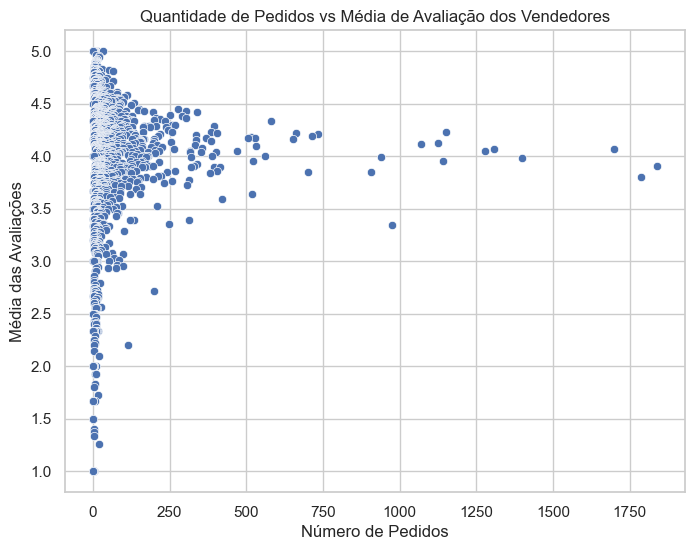

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=resultado,
    x="num_pedidos",
    y="avg_review"
)

plt.title("Quantidade de Pedidos vs Média de Avaliação dos Vendedores")
plt.xlabel("Número de Pedidos")
plt.ylabel("Média das Avaliações")

plt.show()

### Análise do tempo de Entrega dos Pedidos

In [10]:
# Calcular tempo de entrega
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

## Junção de Tempo de Entrega, Avaliação Média e Volume de Pedidos

In [11]:
query_delivery = """
SELECT
    oi.seller_id,
    AVG(o.delivery_time_days) AS avg_delivery_time,
    COUNT(DISTINCT oi.order_id) AS num_pedidos,
    AVG(orv.review_score) AS avg_review

FROM orders o
JOIN order_items oi 
    ON o.order_id = oi.order_id

LEFT JOIN order_reviews orv
    ON o.order_id = orv.order_id

WHERE o.delivery_time_days IS NOT NULL 
  AND o.delivery_time_days > 0

GROUP BY oi.seller_id

HAVING COUNT(DISTINCT oi.order_id) >= 10

ORDER BY avg_delivery_time ASC
"""

top_sellers_delivery = duckdb.query(query_delivery).to_df()
 

In [12]:
bins = [0, 1, 2, 3, 4, 5]
labels = [
    "muito ruim",
    "ruim",
    "ok",
    "bom",
    "excelente"
]

top_sellers_delivery["review_categoria"] = pd.cut(
    top_sellers_delivery["avg_review"],
    bins=bins,
    labels=labels
)

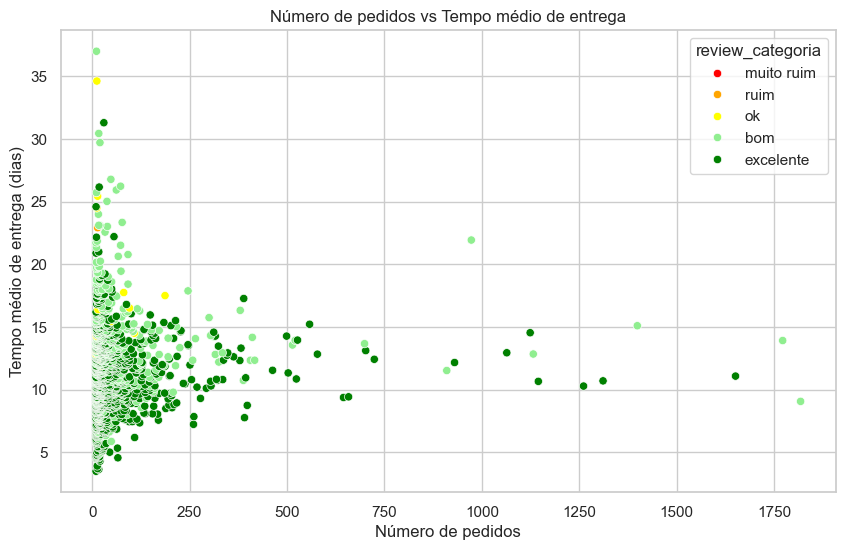

In [13]:
#import seaborn as sns
#import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

cores = [
    "red",
    "orange",
    "yellow",
    "lightgreen",
    "green"
]

sns.scatterplot(
    data=top_sellers_delivery,
    x="num_pedidos",
    y="avg_delivery_time",
    hue="review_categoria",
    palette=cores
)

plt.title("Número de pedidos vs Tempo médio de entrega")
plt.xlabel("Número de pedidos")
plt.ylabel("Tempo médio de entrega (dias)")

plt.show()